In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

### Importing Modules

In [1]:
import pandas as pd

### Data Ingestion

In [ ]:
# Run cronjob seperately to keep updating data after every one minute
# Refer gensim_data_ingestion_ron.py

df = pd.read_csv("data.csv")

### Data Transformation & Segmentation

In [ ]:
from gensim_utils import data_transform, segmentation

# Feature engineering and creating windows for data segmentation
df = data_transform(df, window=5)
df.head()

# Segmenting data into documents based on window size
documents = segmentation(df)
documents[:5]

INFO:template_utils:Segmented data with window size of: 5
INFO:template_utils:Segmented data into documents


[['stable', 'medium_up', 'stable', 'stable', 'medium_down'],
 ['stable', 'large_up', 'stable', 'medium_up', 'stable'],
 ['medium_up', 'stable', 'stable', 'stable', 'stable'],
 ['medium_up', 'large_up', 'medium_up', 'medium_up', 'large_up'],
 ['large_up', 'large_up', 'medium_up', 'large_up', 'large_up']]

### Vectorization

In [ ]:
from gensim_utils import word2vec, fasttext, doc_tagger, do2vec

# Creating a Word2Vec Model
w2v_model = word2vec(documents)

# Creating a FastText Vector Model
ft_model = fasttext(documents)

# Creating a Doc2Vec Model
tagged_docs = doc_tagger(documents)
d2v_model = do2vec(tagged_docs)

INFO:template_utils:Vectorization completed using Word2Vec Model
INFO:template_utils:Vectorization completed using FastText Model
INFO:template_utils:Document Tagging completed
INFO:template_utils:Document Vectorization completed using Doc2Vec Model


### Topic Modeling

In [ ]:
from gensim_utils import corpus_creation, lda_modeling, lsi_modeling

# Creating dictionary and corpus for our topic models
dictionary, corpus = corpus_creation(documents)

# Creating LDA Model with 2 topics
lda_model = lda_modeling(dictionary, corpus, num_topics=2)

# Creating LSI Model with 2 topics
lsi_model = lsi_modeling(dictionary, corpus, num_topics=2)

INFO:template_utils:Dictionary and Corpus created for Topic Modeling


LDA Modeling done with the following topics:
(0, '0.867*"stable" + 0.089*"medium_down" + 0.024*"large_down" + 0.018*"medium_up" + 0.002*"large_up"')
(1, '0.470*"medium_up" + 0.284*"stable" + 0.231*"large_up" + 0.009*"medium_down" + 0.006*"large_down"')
LSI Modeling done with the following topics:
(0, '0.992*"stable" + 0.106*"medium_up" + 0.060*"medium_down" + 0.026*"large_up" + 0.014*"large_down"')
(1, '0.802*"medium_up" + 0.587*"large_up" + -0.098*"stable" + -0.047*"medium_down" + -0.012*"large_down"')


### Analysis & Report

In [ ]:
from gensim_utils import sub_dataframe

# Pull out a specific row (e.g., for the 0th time window)
sub_dataframe(df, 0)

time           22:11:03.919435
price                    84218
date                2025-04-13
perc_change                0.0
movement                stable
window                       0
Name: 0, dtype: object

In [ ]:
from gensim_utils import vector_model_topic_similarity

# Word2Vec
similarity_df_w2v = vector_model_topic_similarity(w2v_model)
print("Similarity matrix based on Word2Vec Model")
# print(vector_model_topic_similarity.__doc__)
print(similarity_df_w2v,'\n')

# FastText
similarity_df_fasttext = vector_model_topic_similarity(ft_model)
print("Similarity matrix based on FastText Model")
# print(vector_model_topic_similarity.__doc__)
print(similarity_df_fasttext,'\n')

# Doc2Vec
similarity_df_d2v = vector_model_topic_similarity(d2v_model)
print("Similarity matrix based on Doc2Vec Model")
# print(vector_model_topic_similarity.__doc__)
print(similarity_df_d2v,'\n')


Similarity matrix based on Word2Vec Model
               stable  medium_up  medium_down  large_up  large_down
stable       1.000000   0.056507     0.133226 -0.002911   -0.112644
medium_up    0.056507   1.000000     0.016674 -0.163587    0.128055
medium_down  0.133226   0.016674     1.000000 -0.149741    0.166800
large_up    -0.002911  -0.163587    -0.149741  1.000000   -0.202517
large_down  -0.112644   0.128055     0.166800 -0.202517    1.000000 

Similarity matrix based on FastText Model
               stable  medium_up  medium_down  large_up  large_down
stable       1.000000  -0.122039    -0.030344  0.062378    0.116082
medium_up   -0.122039   1.000000     0.570972 -0.021639   -0.136359
medium_down -0.030344   0.570972     1.000000 -0.253436    0.153042
large_up     0.062378  -0.021639    -0.253436  1.000000    0.467940
large_down   0.116082  -0.136359     0.153042  0.467940    1.000000 

Similarity matrix based on Doc2Vec Model
               stable  medium_up  medium_down  large_up

In [ ]:
from gensim_utils import vecmodel_window_similarity

# Selecting two time windows (documents)
doc1 = documents[3]
doc2 = documents[-1]

# print(vecmodel_window_similarity.__doc__)
print("Doc1:", doc1)
print("Doc2:", doc2)

# Similarity based on Word2Vec Model
print("Similarity based on Word2Vec Model")
vecmodel_window_similarity(w2v_model, doc1, doc2)

# Similarity based on FastText Model
print("Similarity based on FastText Model")
vecmodel_window_similarity(ft_model, doc1, doc2)

# Similarity based on Doc2Vec Model
print("Similarity based on Doc2Vec Model")
vecmodel_window_similarity(d2v_model, doc1, doc2)


Doc1: ['medium_up', 'large_up', 'medium_up', 'medium_up', 'large_up']
Doc2: ['stable', 'stable', 'stable', 'medium_up']
Similarity: 0.2602
Similarity: 0.2468
Similarity: 0.2677


In [ ]:
from gensim_utils import similar_d2v_time

# Use the most recent document
doc = documents[-1]

# print(similar_d2v_time.__doc__)
similar_d2v_time(df, d2v_model, doc)

Top 5 similar timeframes
Timeframe: 2025-04-13, 22:56:09.922406 To 2025-04-13, 23:00:10.413999 Similarity: 0.4559078812599182
Timeframe: 2025-04-28, 18:34:50.307150 To 2025-04-28, 18:38:51.040606 Similarity: 0.2916572093963623
Timeframe: 2025-04-29, 13:28:57.086811 To 2025-04-29, 13:32:57.511139 Similarity: 0.28267529606819153
Timeframe: 2025-04-29, 13:18:55.612361 To 2025-04-29, 13:22:56.158488 Similarity: 0.2766205370426178
Timeframe: 2025-04-29, 13:03:23.201708 To 2025-04-29, 13:07:23.718568 Similarity: 0.2728700637817383


In [ ]:
from gensim_utils import similar_w2v_time, sub_dataframe

# Document for which we want similar windows
index = -1
doc = documents[index]

# print(similar_w2v_time.__doc__)

print("\nTimestamp for which we are finding similar windows")
print(sub_dataframe(df, index))

print("\nSimilar windows based on Word2Vec Model")
similar_w2v_time(df, w2v_model, documents, doc, topn=5)

print("\nSimilar windows based on FastText Model")
similar_w2v_time(df, ft_model, documents, doc, topn=5)



Timestamp for which we are finding similar windows
time           21:59:14.735654
price                    94502
date                2025-04-29
perc_change           0.029638
movement             medium_up
window                      99
Name: 498, dtype: object

Similar windows based on Word2Vec Model
Top 5 similar timeframes:
Timeframe: 2025-04-29, 21:56:14.202722 To 2025-04-29, 21:59:14.735654 Similarity: 1.0000
Timeframe: 2025-04-29, 13:23:56.301408 To 2025-04-29, 13:27:56.974689 Similarity: 0.9978
Timeframe: 2025-04-28, 15:34:28.530270 To 2025-04-28, 15:38:29.186050 Similarity: 0.9978
Timeframe: 2025-04-28, 15:39:29.322454 To 2025-04-28, 15:43:29.989950 Similarity: 0.9978
Timeframe: 2025-04-28, 20:39:19.244032 To 2025-04-28, 20:43:20.053251 Similarity: 0.9978

Similar windows based on FastText Model
Top 5 similar timeframes:
Timeframe: 2025-04-29, 21:56:14.202722 To 2025-04-29, 21:59:14.735654 Similarity: 1.0000
Timeframe: 2025-04-28, 20:39:19.244032 To 2025-04-28, 20:43:20.053251

In [ ]:
from gensim_utils import d2v_cosine_sim

# print(d2v_cosine_sim.__doc__)
d2v_cosine_sim(d2v_model, tagged_docs)

Top 10 similar pairs
Windows 8 & 27 → Similarity: 0.5301
Windows 0 & 80 → Similarity: 0.4630
Windows 9 & 80 → Similarity: 0.4486
Windows 25 & 83 → Similarity: 0.4405
Windows 1 & 8 → Similarity: 0.4389
Windows 17 & 72 → Similarity: 0.4383
Windows 2 & 33 → Similarity: 0.4121
Windows 28 & 89 → Similarity: 0.4110
Windows 44 & 85 → Similarity: 0.3984
Windows 57 & 90 → Similarity: 0.3940


Top 20 most similar time windows:
Windows 27 & 97 → Similarity: 1.0000
Windows 9 & 10 → Similarity: 1.0000
Windows 14 & 16 → Similarity: 1.0000
Windows 14 & 17 → Similarity: 1.0000
Windows 14 & 20 → Similarity: 1.0000
Windows 14 & 24 → Similarity: 1.0000
Windows 14 & 25 → Similarity: 1.0000
Windows 14 & 26 → Similarity: 1.0000
Windows 14 & 28 → Similarity: 1.0000
Windows 14 & 29 → Similarity: 1.0000


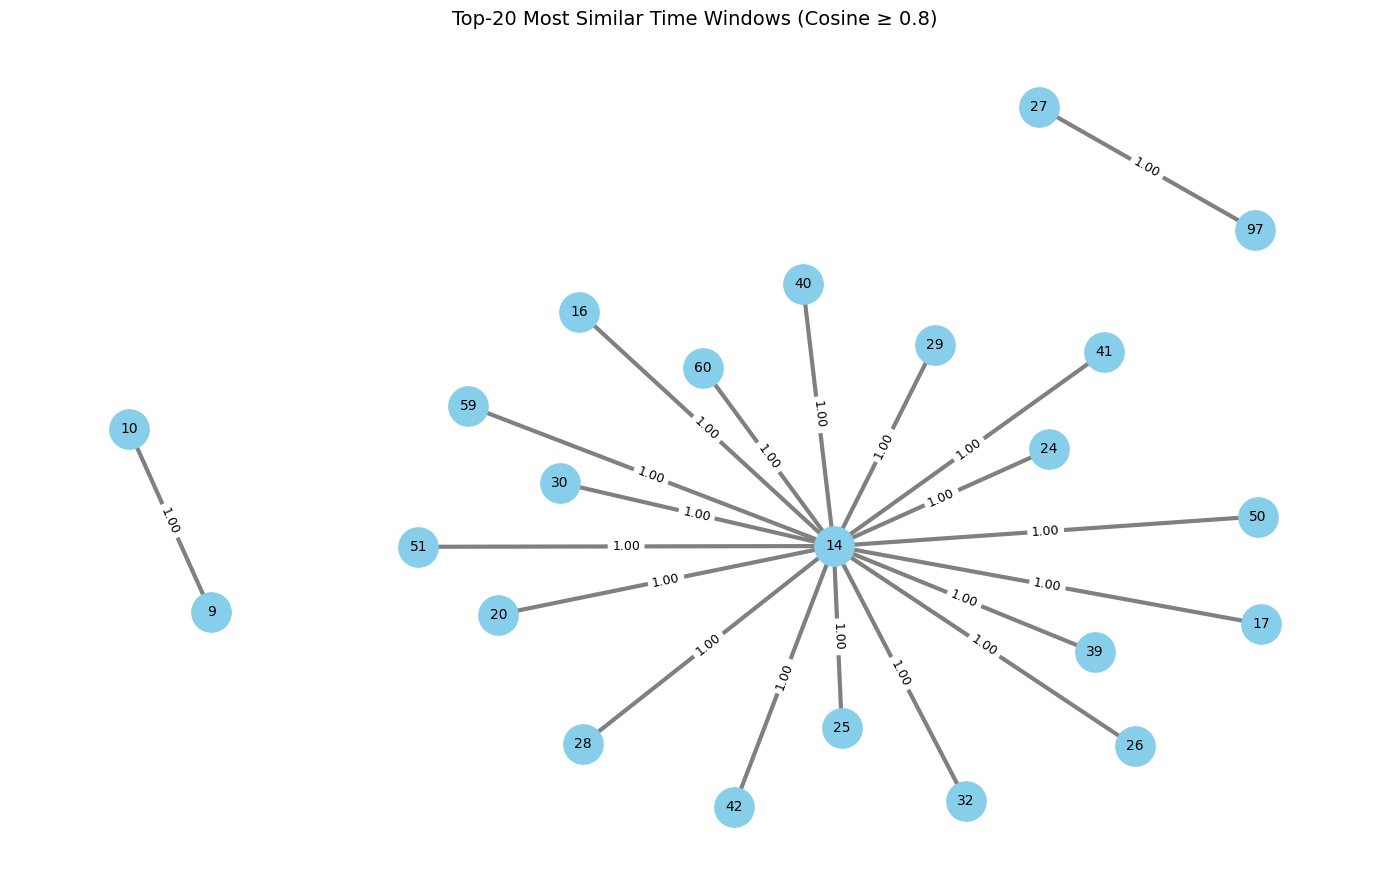

Investment Confidence Score (Last 5 windows): 85.19/100


In [ ]:
from gensim_utils import word2v_cosine_sim

# Visualize similarity graph and calculate confidence - Word2Vec
word2v_cosine_sim(w2v_model, documents, top_k=20, threshold=0.8)

Top 20 most similar time windows:
Windows 1 & 5 → Similarity: 1.0000
Windows 1 & 12 → Similarity: 1.0000
Windows 1 & 87 → Similarity: 1.0000
Windows 5 & 12 → Similarity: 1.0000
Windows 5 & 87 → Similarity: 1.0000
Windows 6 & 49 → Similarity: 1.0000
Windows 11 & 49 → Similarity: 1.0000
Windows 33 & 49 → Similarity: 1.0000
Windows 36 & 49 → Similarity: 1.0000
Windows 38 & 49 → Similarity: 1.0000


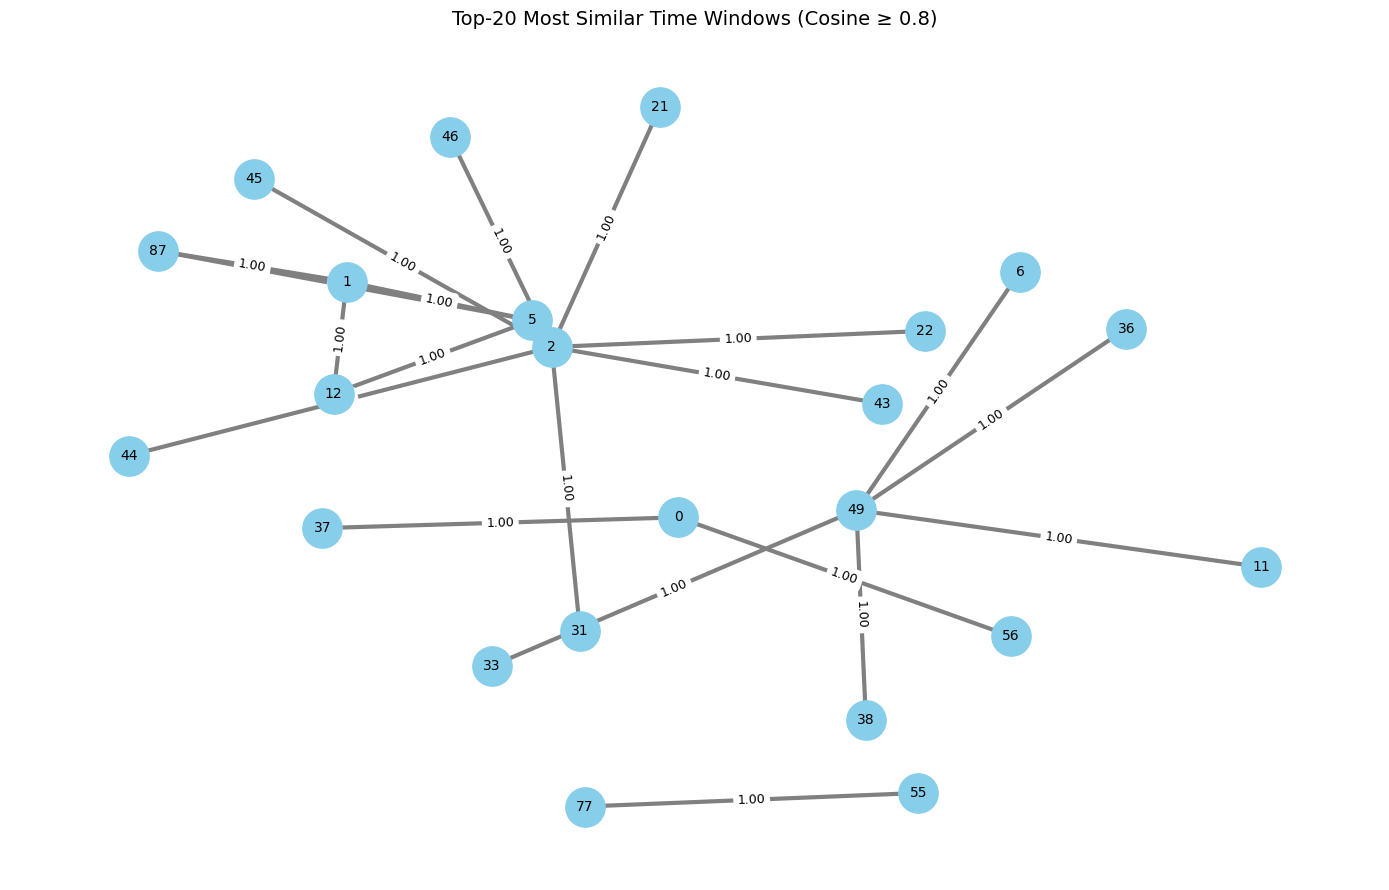

Investment Confidence Score (Last 5 windows): 87.66/100


In [13]:
# Visualize similarity graph and calculate confidence - FastText
word2v_cosine_sim(ft_model,documents, top_k=20, threshold=0.8)

In [ ]:
from gensim_utils import topic_model_cos_sim, combine_topic_signals

lda_result = topic_model_cos_sim(lda_model, corpus)  # returns (trend, confidence)
lsi_result = topic_model_cos_sim(lsi_model, corpus)  # returns (trend, confidence)

combine_topic_signals(lda_result, lsi_result)

🔍 LDA → Trend: Bearish | Confidence: 91.95
🔍 LSI → Trend: Bearish | Confidence: 96.86
✅ Consensus Recommendation: BEARISH — Both models agree with high confidence.
